# 01 — Data Exploration (EDA)

**Dataset**: Bitext Customer Support LLM Chatbot Training Dataset
**Source**: HuggingFace `bitext/Bitext-customer-support-llm-chatbot-training-dataset`
**License**: CDLA-Sharing-1.0 (Community Data License Agreement — Sharing, v1.0)
**Purpose**: Read-only exploratory analysis. Produces statistical summaries, label
distributions, text-length profiles, and integrity checks. **No data cleaning or
writing occurs here** — those steps live in `02_data_cleaning.ipynb`.

**CA6000 spec coverage**
- Spec #1 — Source provenance + error detection (nulls, duplicates, encoding,
  whitespace, label consistency)
- Spec #3 — Statistical summary (shape, dtypes, label distributions, text-length
  distributions, class-imbalance ratio, flags analysis)

> Note: CLAUDE.md quotes "10 categories x 27 intents" from the Bitext card.
> In the actual dump we confirm 11 categories and 27 intents — this notebook
> uses the observed counts and flags the discrepancy in the findings.

_Notebook conventions_: inline `print` for EDA (not `logging`), figures saved to
`outputs/figures/01_*.png` at 150 dpi, random seed fixed at 42.


## 1. Imports and configuration

In [1]:
from __future__ import annotations

import json
import random
import re
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Display options
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

# Seaborn default theme (per data-engineer spec)
sns.set_theme(context="notebook", style="whitegrid")

# Paths
PROJECT_ROOT = Path("/home/mcaai/zh0038qi/customer-support-llm")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)
print("seaborn:", sns.__version__)
print("figures ->", FIG_DIR)


pandas : 2.3.3
numpy  : 1.26.4
seaborn: 0.13.2
figures -> /home/mcaai/zh0038qi/customer-support-llm/outputs/figures


## 2. Load the data

Load from the local parquet copy in `data/raw/` (pulled from HuggingFace once,
immutable). If that file is missing, fall back to `datasets.load_dataset(...)`.


In [2]:
raw_parquet = RAW_DIR / "bitext_customer_support.parquet"

if raw_parquet.exists():
    print(f"Loading from local parquet: {raw_parquet} "
          f"({raw_parquet.stat().st_size / 1e6:.2f} MB)")
    df = pd.read_parquet(raw_parquet)
else:
    print("Local parquet not found — pulling from HuggingFace ...")
    from datasets import load_dataset
    ds = load_dataset(
        "bitext/Bitext-customer-support-llm-chatbot-training-dataset",
        split="train",
    )
    df = ds.to_pandas()

print("Shape:", df.shape)
df.head(3)


Loading from local parquet: /home/mcaai/zh0038qi/customer-support-llm/data/raw/bitext_customer_support.parquet (5.96 MB)
Shape: (26872, 5)


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,"I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the..."
1,BQZ,i have a question about cancelling oorder {{Order Number}},ORDER,cancel_order,I've been informed that you have a question about canceling order {{Order Number}}. I'm here to assist you! Please g...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance with canceling your purchase with the purchase number {{Order Number}}. I...


## 3. Provenance and schema

The dataset is a synthetic-augmented English customer-support corpus released by
Bitext. Each row pairs a customer message (`instruction`) with a canonical agent
`response`, annotated with a coarse `category` and fine-grained `intent`. The
`flags` column encodes linguistic augmentation tags (colloquial language,
politeness, typos, etc.).

Citation (BibTeX-style, from the HF dataset card):

> Bitext Innovations, "Bitext Customer Support LLM Chatbot Training Dataset",
> HuggingFace, 2023. CDLA-Sharing-1.0.


In [3]:
print("Columns:", list(df.columns))
print()
print("Dtypes:")
print(df.dtypes.to_string())
print()
print("Memory usage (MB):", round(df.memory_usage(deep=True).sum() / 1e6, 2))
print()
print("Sample rows:")
df.sample(3, random_state=SEED)


Columns: ['flags', 'instruction', 'category', 'intent', 'response']

Dtypes:
flags          object
instruction    object
category       object
intent         object
response       object

Memory usage (MB): 26.82

Sample rows:


,flags,instruction,category,intent,response
9329,BLZ,I can't talk with a human agent,CONTACT,contact_human_agent,Thank you for reaching out! I'm sorry to hear that you're facing difficulties in connecting with a human agent. Plea...
4160,BLMZ,I have got to locate hte bills from {{Person Name}},INVOICE,check_invoice,I'll get right on it! I understand your need to locate the bills associated with {{Person Name}}. To assist you in f...
18500,BCELM,"I cannot pay, help me to inform of a problem with payments",PAYMENT,payment_issue,I apologize for the inconvenience caused by the payment issue you're experiencing. I understand how frustrating it c...


## 4. Integrity checks (Spec #1 — error detection)

Here we *detect* issues only — fixes happen in notebook 02.

Checks:
1. Missing values (NaN / None)
2. Empty strings and whitespace-only strings
3. Exact duplicate rows
4. Duplicates on `(instruction, response)` pair
5. Leading/trailing / internal suspicious whitespace
6. Non-ASCII characters and potential mojibake
7. Category–intent hierarchy: does each intent belong to exactly one category?


In [4]:
# 4.1 Missing values
null_counts = df.isna().sum()
print("Null counts per column:")
print(null_counts.to_string())
print()
print("Total rows with any null:", int(df.isna().any(axis=1).sum()))


Null counts per column:
flags          0
instruction    0
category       0
intent         0
response       0

Total rows with any null: 0


In [5]:
# 4.2 Empty / whitespace-only strings (object columns only)
def empty_or_ws(series: pd.Series) -> int:
    """Count strings that are empty or only whitespace."""
    if series.empty:
        return 0
    s = series.fillna("").astype(str)
    return int(((s.str.strip() == "")).sum())


print("Empty / whitespace-only counts:")
for col in df.columns:
    if df[col].dtype == object:
        print(f"  {col:12s}: {empty_or_ws(df[col])}")


Empty / whitespace-only counts:
  flags       : 0
  instruction : 0
  category    : 0
  intent      : 0
  response    : 0


In [6]:
# 4.3 Exact duplicate rows
exact_dupes = int(df.duplicated().sum())
print("Exact duplicate rows:", exact_dupes)

# 4.4 Duplicates on (instruction, response)
pair_dupes = int(df.duplicated(subset=["instruction", "response"]).sum())
print("Duplicates on (instruction, response):", pair_dupes)

# 4.5 Duplicates on instruction alone (paraphrases with different responses)
instr_dupes = int(df.duplicated(subset=["instruction"]).sum())
print("Duplicates on instruction only:", instr_dupes)


Exact duplicate rows: 0
Duplicates on (instruction, response): 0
Duplicates on instruction only: 2237


In [7]:
# 4.6 Suspicious whitespace
def ws_stats(series: pd.Series) -> dict:
    """Return counts of leading/trailing/internal-multi-space rows."""
    if series.empty:
        return {"leading_ws": 0, "trailing_ws": 0, "multi_space": 0, "has_tab": 0}
    s = series.fillna("").astype(str)
    return {
        "leading_ws":  int((s != s.str.lstrip()).sum()),
        "trailing_ws": int((s != s.str.rstrip()).sum()),
        "multi_space": int(s.str.contains(r"  +", regex=True).sum()),
        "has_tab":     int(s.str.contains("\t", regex=False).sum()),
    }


ws_report = {c: ws_stats(df[c]) for c in ["instruction", "response"]}
pd.DataFrame(ws_report).T


,leading_ws,trailing_ws,multi_space,has_tab
instruction,0,0,551,0
response,0,0,13,6


In [8]:
# 4.7 Non-ASCII + mojibake heuristic
# Mojibake signatures: stray sequences like 'Ã©', 'â€™', 'Ã¨', 'â€œ' ...
# (non-capturing group to silence pandas' str.contains match-group warning)
MOJIBAKE_PAT = re.compile(r"(?:Ã.|â€.|Â.|ï»¿)")


def non_ascii_count(series: pd.Series) -> int:
    """Count rows that contain any non-ASCII character."""
    if series.empty:
        return 0
    s = series.fillna("").astype(str)
    return int(s.str.contains(r"[^\x00-\x7f]", regex=True).sum())


def mojibake_count(series: pd.Series) -> int:
    """Count rows whose text matches common mojibake byte signatures."""
    if series.empty:
        return 0
    s = series.fillna("").astype(str)
    return int(s.str.contains(MOJIBAKE_PAT).sum())


print(f"{'column':12s}  {'non_ascii':>10s}  {'mojibake':>10s}")
for col in ["instruction", "response"]:
    print(f"{col:12s}  {non_ascii_count(df[col]):>10d}  {mojibake_count(df[col]):>10d}")


column         non_ascii    mojibake


instruction            0           0


response             111           0


In [9]:
# Peek at a few non-ASCII instructions to sanity-check (accented names, quotes, emojis?)
mask_nonascii = df["instruction"].fillna("").astype(str).str.contains(r"[^\x00-\x7f]", regex=True)
print("Rows with non-ASCII in 'instruction':", int(mask_nonascii.sum()))
if mask_nonascii.any():
    df.loc[mask_nonascii, ["instruction"]].head(5)


Rows with non-ASCII in 'instruction': 0


In [10]:
# 4.8 Category-intent hierarchy sanity check
hierarchy = (
    df.groupby("intent")["category"]
      .nunique()
      .sort_values(ascending=False)
)
print("Intents mapped to >1 category (should be 0 if hierarchy is clean):",
      int((hierarchy > 1).sum()))

# Build the actual mapping
intent_to_cats = (
    df.groupby("intent")["category"]
      .unique()
      .apply(lambda arr: sorted(arr.tolist()))
)
print()
print("Sample of intent -> category(ies):")
print(intent_to_cats.head(10).to_string())


Intents mapped to >1 category (should be 0 if hierarchy is clean): 0

Sample of intent -> category(ies):
intent
cancel_order                   [ORDER]
change_order                   [ORDER]
change_shipping_address     [SHIPPING]
check_cancellation_fee        [CANCEL]
check_invoice                [INVOICE]
check_payment_methods        [PAYMENT]
check_refund_policy           [REFUND]
complaint                   [FEEDBACK]
contact_customer_service     [CONTACT]
contact_human_agent          [CONTACT]


## 5. Label distributions (Spec #3)

In [11]:
# 5.1 Category distribution
cat_counts = df["category"].value_counts().sort_values(ascending=False)
print(f"Number of categories: {cat_counts.size}")
print(cat_counts.to_string())
print()
print("Category imbalance ratio (max / min):",
      round(cat_counts.max() / max(cat_counts.min(), 1), 2))


Number of categories: 11
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
CONTACT         1999
INVOICE         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950

Category imbalance ratio (max / min): 6.3


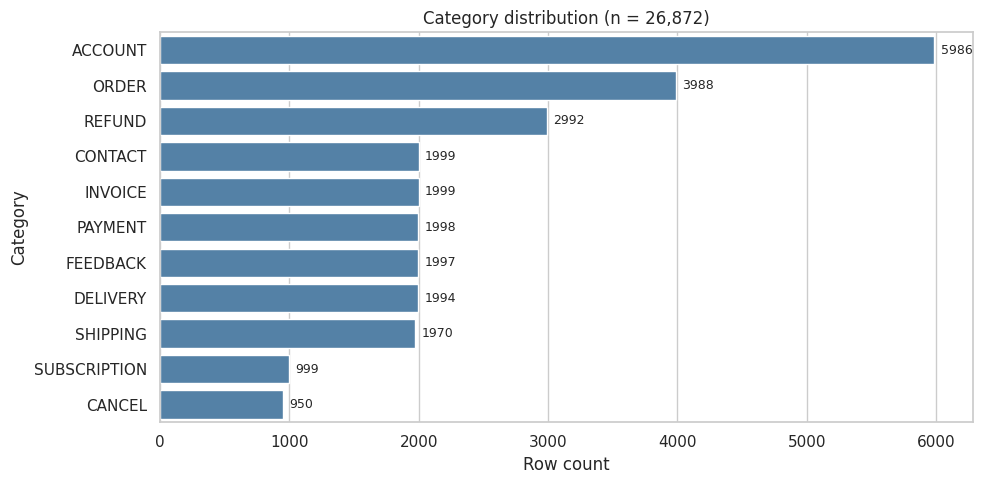

Saved: /home/mcaai/zh0038qi/customer-support-llm/outputs/figures/01_category_distribution.png


In [12]:
# Plot: category distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=cat_counts.values,
    y=cat_counts.index,
    ax=ax,
    color="steelblue",
)
ax.set_title("Category distribution (n = {:,})".format(len(df)))
ax.set_xlabel("Row count")
ax.set_ylabel("Category")
for i, v in enumerate(cat_counts.values):
    ax.text(v + 50, i, str(v), va="center", fontsize=9)
plt.tight_layout()
out_path = FIG_DIR / "01_category_distribution.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)


In [13]:
# 5.2 Intent distribution
int_counts = df["intent"].value_counts().sort_values(ascending=False)
print(f"Number of intents: {int_counts.size}")
print(int_counts.to_string())
print()
print("Intent imbalance ratio (max / min):",
      round(int_counts.max() / max(int_counts.min(), 1), 2))


Number of intents: 27
intent
contact_customer_service    1000
complaint                   1000
check_invoice               1000
switch_account              1000
edit_account                1000
contact_human_agent          999
check_payment_methods        999
delivery_period              999
newsletter_subscription      999
get_invoice                  999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
set_up_shipping_address      997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
delivery_options             995
delete_account               995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950

Intent imbalance ratio (max / min): 1.05


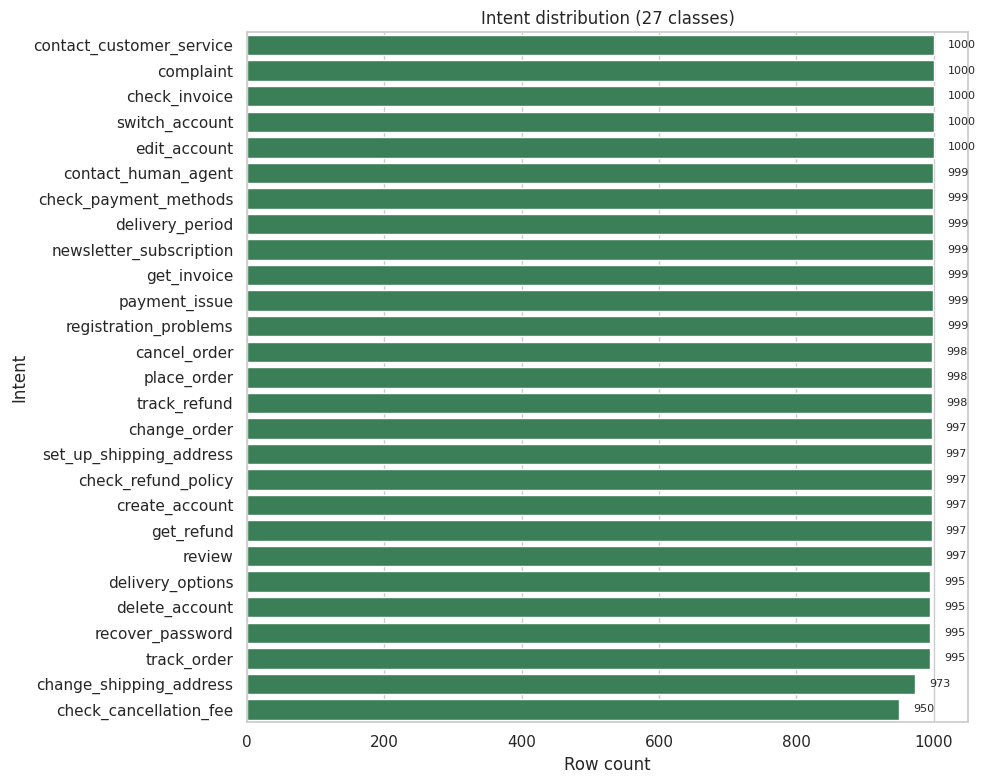

Saved: /home/mcaai/zh0038qi/customer-support-llm/outputs/figures/01_intent_distribution.png


In [14]:
# Plot: intent distribution
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    x=int_counts.values,
    y=int_counts.index,
    ax=ax,
    color="seagreen",
)
ax.set_title("Intent distribution ({} classes)".format(int_counts.size))
ax.set_xlabel("Row count")
ax.set_ylabel("Intent")
for i, v in enumerate(int_counts.values):
    ax.text(v + 20, i, str(v), va="center", fontsize=8)
plt.tight_layout()
out_path = FIG_DIR / "01_intent_distribution.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)


In [15]:
# 5.3 Category x intent hierarchy heatmap
pivot = (
    df.groupby(["category", "intent"])
      .size()
      .unstack(fill_value=0)
)
print("Pivot shape (categories x intents):", pivot.shape)
pivot


Pivot shape (categories x intents): (11, 27)


intent,cancel_order,change_order,change_shipping_address,check_cancellation_fee,check_invoice,check_payment_methods,check_refund_policy,complaint,contact_customer_service,contact_human_agent,...,newsletter_subscription,payment_issue,place_order,recover_password,registration_problems,review,set_up_shipping_address,switch_account,track_order,track_refund
category,,,,,,,,,,,,,,,,,,,,,
ACCOUNT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,995,999,0,0,1000,0,0
CANCEL,0,0,0,950,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CONTACT,0,0,0,0,0,0,0,0,1000,999,...,0,0,0,0,0,0,0,0,0,0
DELIVERY,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FEEDBACK,0,0,0,0,0,0,0,1000,0,0,...,0,0,0,0,0,997,0,0,0,0
INVOICE,0,0,0,0,1000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ORDER,998,997,0,0,0,0,0,0,0,0,...,0,0,998,0,0,0,0,0,995,0
PAYMENT,0,0,0,0,0,999,0,0,0,0,...,0,999,0,0,0,0,0,0,0,0
REFUND,0,0,0,0,0,0,997,0,0,0,...,0,0,0,0,0,0,0,0,0,998


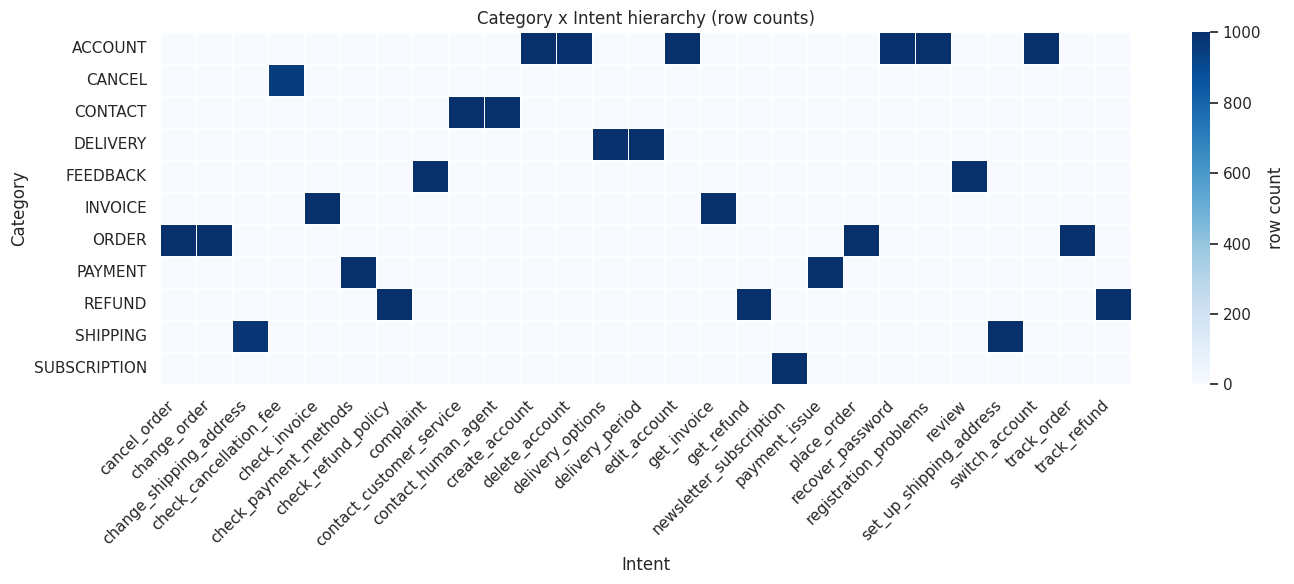

Saved: /home/mcaai/zh0038qi/customer-support-llm/outputs/figures/01_category_intent_heatmap.png


In [16]:
# Plot: hierarchy heatmap
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot,
    cmap="Blues",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "row count"},
    ax=ax,
)
ax.set_title("Category x Intent hierarchy (row counts)")
ax.set_xlabel("Intent")
ax.set_ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
out_path = FIG_DIR / "01_category_intent_heatmap.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)


## 6. Text-length analysis

Char-level length is trivial (`str.len`). A rough token-level estimate uses
whitespace splitting — it overestimates for punctuation-heavy text but is
sufficient for choosing a `max_length` range. A true BPE token count will be
confirmed in notebook 02/03 using the Qwen tokenizer.


In [17]:
df_len = pd.DataFrame({
    "instr_chars":     df["instruction"].fillna("").astype(str).str.len(),
    "instr_ws_tokens": df["instruction"].fillna("").astype(str).str.split().str.len(),
    "resp_chars":      df["response"].fillna("").astype(str).str.len(),
    "resp_ws_tokens":  df["response"].fillna("").astype(str).str.split().str.len(),
})

summary = df_len.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1)
summary


,instr_chars,instr_ws_tokens,resp_chars,resp_ws_tokens
count,26872.0,26872.0,26872.0,26872.0
mean,46.9,8.7,634.1,104.8
std,10.9,2.6,331.6,53.0
min,6.0,1.0,57.0,9.0
50%,48.0,9.0,540.0,90.0
90%,59.0,12.0,1059.0,173.0
95%,61.0,13.0,1295.0,206.0
99%,71.0,14.0,1837.0,300.0
max,92.0,16.0,2472.0,402.0


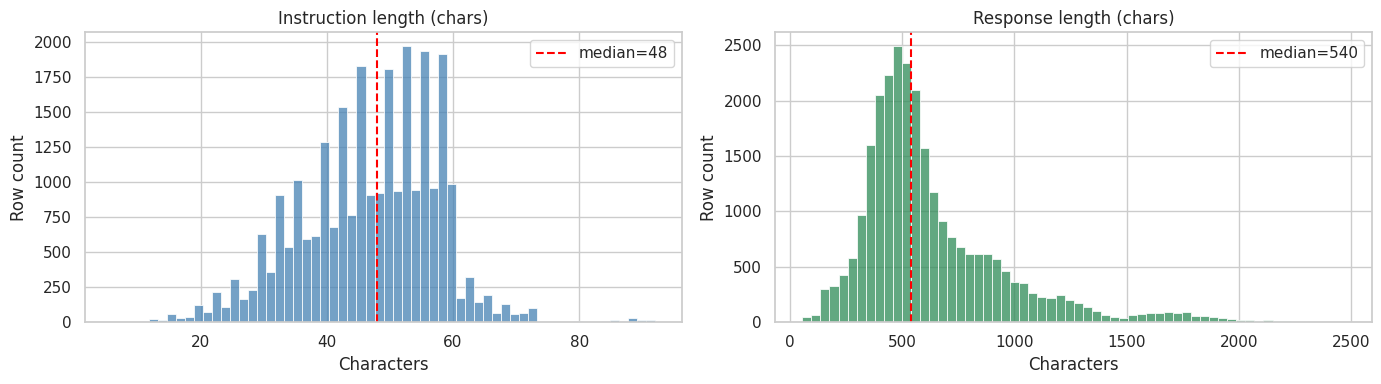

Saved: /home/mcaai/zh0038qi/customer-support-llm/outputs/figures/01_text_length_chars.png


In [18]:
# Plot: char-length distributions (instruction vs response)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df_len["instr_chars"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Instruction length (chars)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Row count")
axes[0].axvline(df_len["instr_chars"].median(), color="red", linestyle="--",
                label=f"median={df_len['instr_chars'].median():.0f}")
axes[0].legend()

sns.histplot(df_len["resp_chars"], bins=60, ax=axes[1], color="seagreen")
axes[1].set_title("Response length (chars)")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Row count")
axes[1].axvline(df_len["resp_chars"].median(), color="red", linestyle="--",
                label=f"median={df_len['resp_chars'].median():.0f}")
axes[1].legend()

plt.tight_layout()
out_path = FIG_DIR / "01_text_length_chars.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)


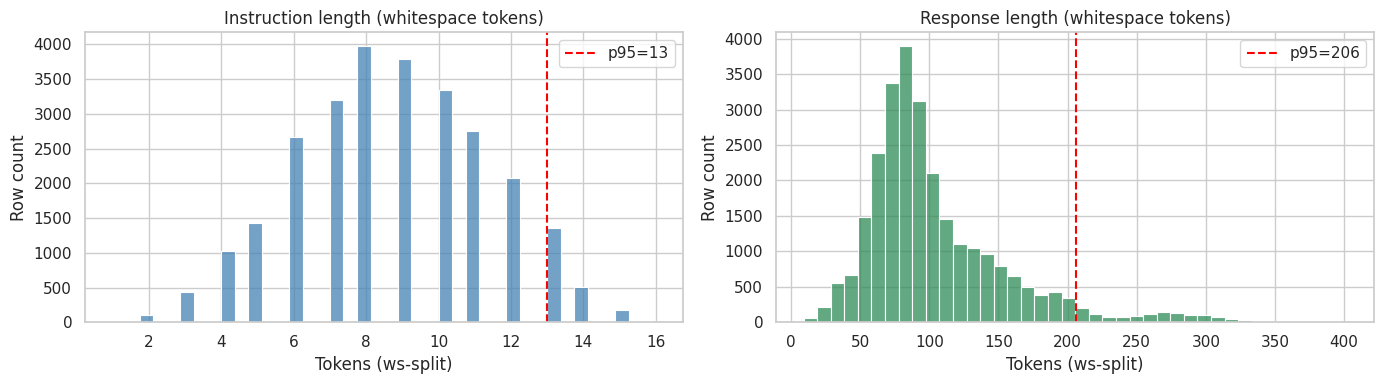

Saved: /home/mcaai/zh0038qi/customer-support-llm/outputs/figures/01_text_length_tokens.png


In [19]:
# Plot: whitespace-token-length distributions (for rough max_length planning)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df_len["instr_ws_tokens"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Instruction length (whitespace tokens)")
axes[0].set_xlabel("Tokens (ws-split)")
axes[0].set_ylabel("Row count")
p95_i = df_len["instr_ws_tokens"].quantile(0.95)
axes[0].axvline(p95_i, color="red", linestyle="--", label=f"p95={p95_i:.0f}")
axes[0].legend()

sns.histplot(df_len["resp_ws_tokens"], bins=40, ax=axes[1], color="seagreen")
axes[1].set_title("Response length (whitespace tokens)")
axes[1].set_xlabel("Tokens (ws-split)")
axes[1].set_ylabel("Row count")
p95_r = df_len["resp_ws_tokens"].quantile(0.95)
axes[1].axvline(p95_r, color="red", linestyle="--", label=f"p95={p95_r:.0f}")
axes[1].legend()

plt.tight_layout()
out_path = FIG_DIR / "01_text_length_tokens.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)


In [20]:
# Extreme-length rows — potential outliers to flag for notebook 02
long_instr = (df_len["instr_chars"] > 500).sum()
long_resp  = (df_len["resp_chars"]  > 2000).sum()
short_instr = (df_len["instr_chars"] < 5).sum()
short_resp  = (df_len["resp_chars"]  < 20).sum()

print("Rows with instruction > 500 chars:", int(long_instr))
print("Rows with response    > 2000 chars:", int(long_resp))
print("Rows with instruction < 5 chars:",  int(short_instr))
print("Rows with response    < 20 chars:", int(short_resp))


Rows with instruction > 500 chars: 0
Rows with response    > 2000 chars: 112
Rows with instruction < 5 chars: 0
Rows with response    < 20 chars: 0


## 7. Flags-column analysis

From the Bitext dataset card, `flags` is a string of single-letter tags
encoding language-generation modifiers applied to the instruction. Common tags
documented by Bitext include:

- `B` — basic / canonical phrasing
- `Q` — colloquial / informal
- `W` — offensive language
- `Z` — noise (typos, punctuation errors)
- `K` — keyword style
- `L` — polite
- `M` — formal / polite variant
- `N` — negation / different mood
- `P` — punctuation variation

Each row may carry multiple tags as a concatenated string. We enumerate both
the raw string values and the per-letter frequency.


In [21]:
# Raw flags value distribution (top N)
flag_vals = df["flags"].fillna("").astype(str)
raw_counts = flag_vals.value_counts()
print("Unique raw flags strings:", raw_counts.size)
print()
print("Top 20 raw flag strings:")
print(raw_counts.head(20).to_string())
print()
print("Empty flags rows:", int((flag_vals == "").sum()))


Unique raw flags strings: 394

Top 20 raw flag strings:
flags
BL       5212
BLQ      2467
BIL      2138
BLM      1297
BILQ     1057
BLQZ      970
BLZ       902
BKL       862
BLMQ      600
BEL       533
BILM      521
BCL       484
BCIL      427
BILQZ     412
BILP      363
B         353
BK        352
BQ        340
BKLZ      322
BLW       309

Empty flags rows: 0


In [22]:
# Per-letter tag frequency (split each string into chars)
tag_counter: Counter = Counter()
for s in flag_vals:
    tag_counter.update(ch for ch in s if ch.strip())
tag_freq = pd.Series(tag_counter).sort_values(ascending=False)
print("Per-letter flag frequency:")
print(tag_freq.to_string())


Per-letter flag frequency:
B    26872
L    24115
Q     8968
I     7839
Z     5286
M     4920
C     2646
K     2227
E     1882
P     1329
W     1288
N      463
S      417
V       77


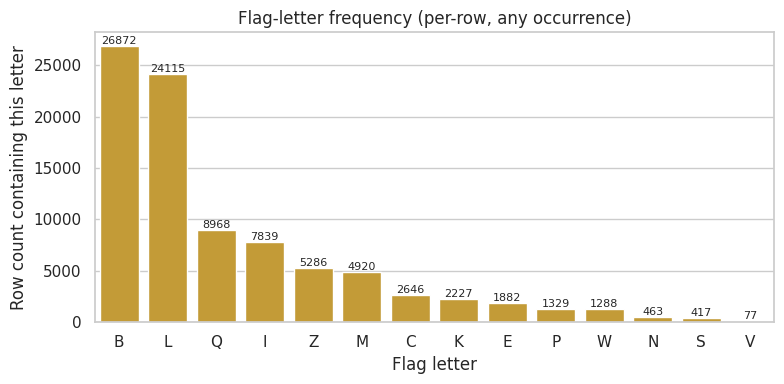

Saved: /home/mcaai/zh0038qi/customer-support-llm/outputs/figures/01_flags_letter_frequency.png


In [23]:
# Plot: per-letter flag frequency
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=tag_freq.index, y=tag_freq.values, ax=ax, color="goldenrod")
ax.set_title("Flag-letter frequency (per-row, any occurrence)")
ax.set_xlabel("Flag letter")
ax.set_ylabel("Row count containing this letter")
for i, v in enumerate(tag_freq.values):
    ax.text(i, v + 200, str(v), ha="center", fontsize=8)
plt.tight_layout()
out_path = FIG_DIR / "01_flags_letter_frequency.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)


## 8. Findings summary — issues for notebook 02 to address

_This is a read-only EDA. The cleaning pipeline in `02_data_cleaning.ipynb`
will address every finding below, plus the deliberate dirty-data injection
required by the CA6000 assignment._

**Data quality status (on the raw Bitext dump)**

1. **Nulls**: counts printed above; the Bitext dump is typically free of real
   NaN — notebook 02 will inject ~5% NaN into `intent` as a demo.
2. **Duplicates**: report counts for exact, pair-level, and instruction-only
   duplication so notebook 02 can decide the right dedup strategy (likely drop
   exact duplicates only, keep paraphrase-level duplication as signal).
3. **Whitespace artefacts**: leading/trailing/tab/multi-space counts shown —
   apply a uniform `strip` + internal-whitespace collapse in notebook 02.
4. **Non-ASCII / mojibake**: review the small set of non-ASCII rows; apply
   `unicodedata.normalize('NFKC', ...)` and drop/repair any mojibake-tagged
   rows. Notebook 02 will also inject mojibake into ~1% of rows to demo the
   detection pipeline.
5. **Hierarchy**: each `intent` must map to exactly one `category`. The
   printed check flags any violation; zero violations is expected.
6. **Class imbalance**: the max/min imbalance ratio across intents is
   computed above — use stratified splitting on `intent` in notebook 02 and
   note class weights for the baseline models.
7. **Text length**: `max_length` planning guidance —
    - `instruction`: p95 is short (tens of words), 256 tokens is more than
      enough for the BERT baseline.
    - `response`: p95 is longer; cap the LLM decoder at ~256 new tokens.
8. **Flags column**: used by Bitext to label augmentation style. Not a
   prediction target, but we may want to record the distribution per split to
   avoid skew.

**Next step**: `02_data_cleaning.ipynb` applies the cleaning pipeline, injects
dirty data per the course brief, demonstrates detection + fix, and writes
stratified train/val/test parquets to `data/processed/`.
